# Parameters

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd

# ===== CONFIGURAÇÃO DE CAMINHOS =====
current_notebook = Path.cwd()  
project_root = current_notebook.parent.parent 

# Adiciona o diretório raiz ao sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Adiciona o diretório Modules ao sys.path
modules_dir = project_root / "Modules"
if str(modules_dir) not in sys.path:
    sys.path.insert(0, str(modules_dir))

# ===== IMPORTS DOS MÓDULOS =====
import Modules.ClusterSHADEModule as cluster
import Modules.FutureAnalysisModule as fa
from Modules.config import CONFIG

# ===== CONFIGURAÇÕES DO PROJETO =====
DATAPATH = CONFIG["datapath"]
COVID_TRAIN_DATA_FILE = CONFIG["covid_train_data_file"]
COVID_TEST_DATA_FILE = CONFIG["covid_test_data_file"]
FUTURE_DATA_FILE = CONFIG["future_data_file"]

CONTROL_GROUP_TRAIN = CONFIG["control_group_train"]
CONTROL_GROUP_TEST = CONFIG["control_group_test"]
CONTROL_GROUP_READMISSION = CONFIG["control_group_readmission"]

FIGSIZE_CLUSTER_HEATMAP = CONFIG["figsize_cluster_heatmap"]
FIGSIZE_FUTURE_HEATMAP = CONFIG["figsize_future_heatmap"]
IMAGES_SAVE_PATH = CONFIG["image_save_path"]
TRIALS_OPTUNA = 250

# Import data

In [2]:
# ===== CARREGAMENTO DOS DADOS =====
data_folder = current_notebook / DATAPATH

covid_train = pd.read_csv(data_folder / COVID_TRAIN_DATA_FILE)
covid_test = pd.read_csv(data_folder / COVID_TEST_DATA_FILE)
future_data = pd.read_csv(data_folder / FUTURE_DATA_FILE)

control_train = pd.read_csv(data_folder / CONTROL_GROUP_TRAIN)
control_test = pd.read_csv(data_folder / CONTROL_GROUP_TEST)
control = pd.concat([control_train, control_test], axis=0)
control_readmission = pd.read_csv(data_folder / CONTROL_GROUP_READMISSION)

# Feature engineering: morte após a internação
covid_train['died_after'] = ((covid_train['died'] == 1) & (covid_train['died_in_stay'] == 0)).astype(int)
covid_test['died_after'] = ((covid_test['died'] == 1) & (covid_test['died_in_stay'] == 0)).astype(int)
future_data['died_after'] = ((future_data['died'] == 1) & (future_data['died_in_stay'] == 0)).astype(int)

In [3]:
data_covid = pd.concat([covid_train, covid_test], axis=0)
data_covid = data_covid.sample(frac=1, random_state=42).reset_index(drop=True)

# Mice Data

In [89]:
categorical_features = [
            "myocardial_infarct",
            "congestive_heart_failure",
            "peripheral_vascular_disease",
            "cerebrovascular_disease",
            "dementia",
            "chronic_pulmonary_disease",
            "rheumatic_disease",
            "peptic_ulcer_disease",
            "mild_liver_disease",
            "diabetes_without_cc",
            "diabetes_with_cc",
            "paraplegia",
            "renal_disease",
            "malignant_cancer",
            "severe_liver_disease",
            "metastatic_solid_tumor",
            "aids",
            "gender_M",
            "died_in_stay",
            "died_after",
            "died",
            "COVID"
        ]

In [5]:
features_not_considered = ['died', 'died_in_stay', 'died_after', 'COVID', 'subject_id', 'hadm_id']

In [6]:
helper = cluster.SHADEClusterHelper(data=data_covid, features_not_considered=features_not_considered)

2026-02-19 21:42:08,187 - ClusterBaseModule - INFO - ClusterBaseHelper initialized: 3355 records, 67 features (22 categorical, 51 numerical)
2026-02-19 21:42:08,187 - Modules.ClusterSHADEModule - INFO - SHADEClusterHelper initialized: 3355 records, scaler='standard'


## Find best hyperparameters for SHADE

In [7]:
param = {
    "batch_size": [64, 128, 256, 500],
    "clustering_epochs": [100, 150, 200],
    "clustering_lr": {"min": 1e-4, "max": 1e-2},
}

### DBCV

In [93]:
# os.environ["PYTHONWARNINGS"] = "ignore"
# dbcv_df, dbcv_param, dbcv_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="dbcv",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80
# )

In [8]:
dbcv_param = {'batch_size': 64, 'clustering_epochs': 100, 'clustering_lr': 0.003890211602331156}

### DISCO

In [9]:
# os.environ['PYTHONWARNINGS'] = 'ignore'
# disco_df, disco_param, disco_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="disco",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80
# )

In [10]:
disco_param = {'batch_size': 500, 'clustering_epochs': 100, 'clustering_lr': 0.006192247528471769}

### DSI

In [11]:
# os.environ['PYTHONWARNINGS'] = 'ignore'
# dsi_df, dsi_param, dsi_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="dsi",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80
# )

In [12]:
dsi_param = {'batch_size': 500, 'clustering_epochs': 150, 'clustering_lr': 0.008008198436051767}

### Silhouette

In [13]:
# os.environ['PYTHONWARNINGS'] = 'ignore'
# silhouette_df, silhouette_param, silhouette_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="silhouette",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80
# )

In [14]:
silhouette_param = {'batch_size': 64, 'clustering_epochs': 100, 'clustering_lr': 0.004225424722098411}

### Metrics

In [15]:
# helper.clustering(
#     batch_size=dbcv_param["batch_size"],
#     clustering_epochs=dbcv_param["clustering_epochs"],
#     clustering_optimizer_params={"lr": dbcv_param["clustering_lr"]},
# )
# helper.getMetrics()

In [16]:
# helper.clustering(
#     batch_size=disco_param["batch_size"],
#     clustering_epochs=disco_param["clustering_epochs"],
#     clustering_optimizer_params={"lr": disco_param["clustering_lr"]},
# )
# helper.getMetrics()

In [17]:
# helper.clustering(
#     batch_size=dsi_param["batch_size"],
#     clustering_epochs=dsi_param["clustering_epochs"],
#     clustering_optimizer_params={"lr": dsi_param["clustering_lr"]},
# )
# helper.getMetrics()

In [18]:
# helper.clustering(
#     batch_size=silhouette_param["batch_size"],
#     clustering_epochs=silhouette_param["clustering_epochs"],
#     clustering_optimizer_params={"lr": silhouette_param["clustering_lr"]},
# )
# helper.getMetrics()

## Best Result - All

In [19]:
best_param = silhouette_param

In [20]:
helper.clustering(
    batch_size=best_param["batch_size"],
    clustering_epochs=best_param["clustering_epochs"],
    clustering_optimizer_params={"lr": best_param["clustering_lr"]},
)
helper.get_metrics()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:36<00:00,  2.75it/s]


2026-02-19 21:43:05,597 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 5 clusters
2026-02-19 21:43:05,597 - Modules.ClusterSHADEModule - INFO - SHADE clustering complete: batch_size=64, clustering_epochs=100
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dis

{'silhouette': 0.117,
 'dbcv': 0.6458975978579832,
 'dsi': np.float64(0.139),
 'disco': np.float64(-0.10780092026113305)}

/Users/gabrielleite/Backup/Mestrado/Mestrado-COVID/Modules/ClusterBaseModule.py:474: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_stats = self._clustered_data.groupby("Cluster").apply(calculate_stats).T
2026-02-19 21:43:11,144 - ClusterBaseModule - INFO - Calculated categorical stats for 5 clusters
/Users/gabrielleite/Backup/Mestrado/Mestrado-COVID/Modules/ClusterBaseModule.py:1448: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.64 x' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot_labels.loc[idx] = df.loc[idx].map(lambda x: f"{x:.2f} x")
/Users/gabrielleite/Bac

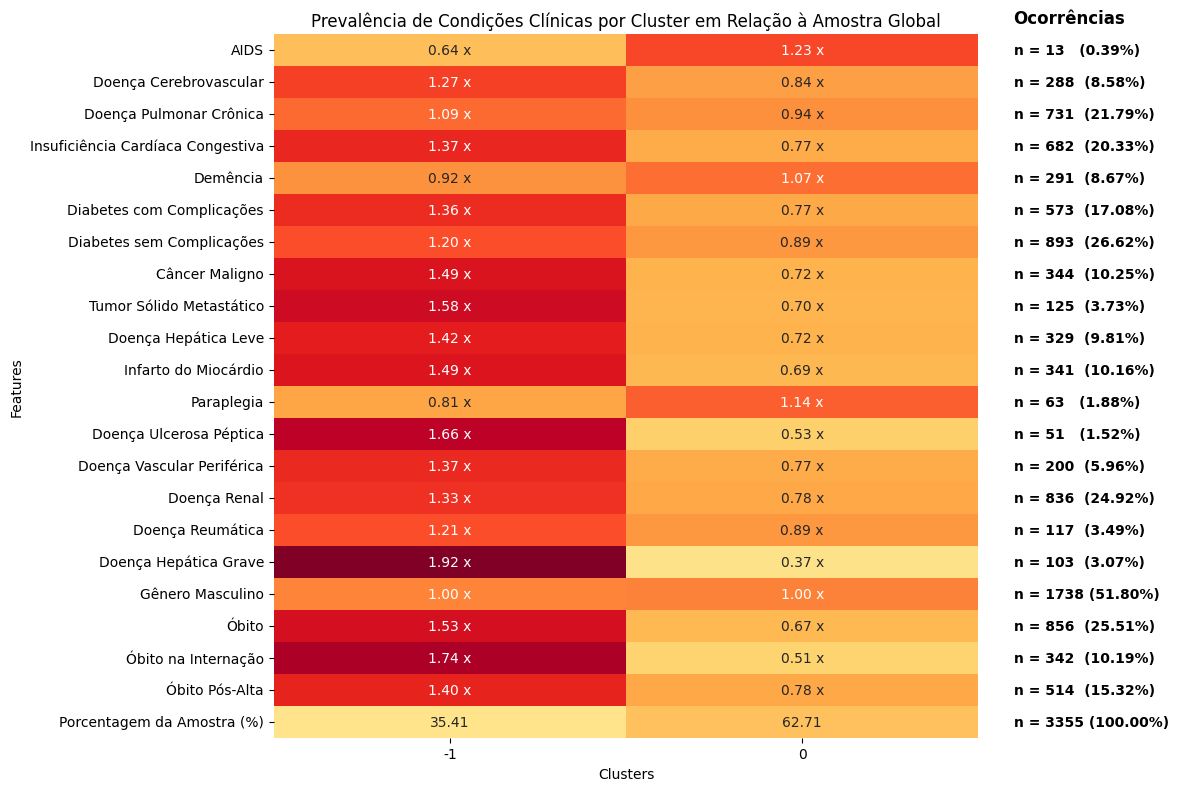

2026-02-19 21:43:11,306 - ClusterBaseModule - INFO - Created categorical heatmap: 22 features, 2 clusters


In [21]:
helper.heatmap_clusters_categorical(
    figsize=FIGSIZE_CLUSTER_HEATMAP,
    # savepath=IMAGES_SAVE_PATH + "shade-all-categorical"
    relative_total=True
)

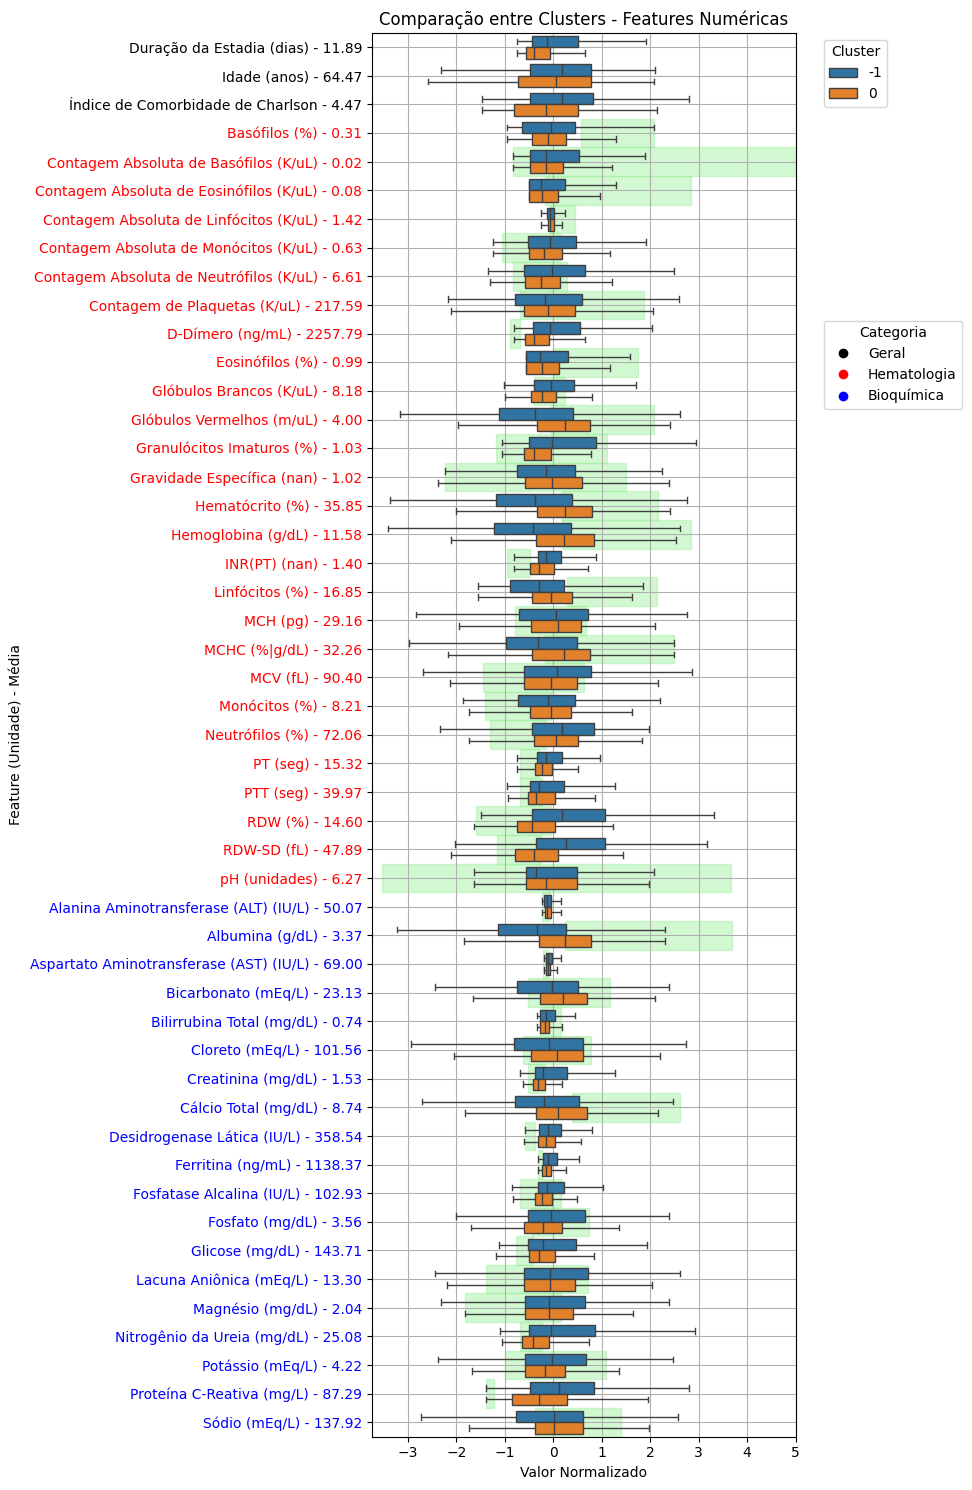

[('RDW-SD_Hematology_Blood_fL', np.float64(2.6981256734558555e-69)),
 ('RDW_Hematology_Blood_%', np.float64(7.791616152468106e-64)),
 ('Albumin_Chemistry_Blood_g/dL', np.float64(2.719704853769256e-57)),
 ('Hemoglobin_Hematology_Blood_g/dL', np.float64(9.252871290656448e-57)),
 ('Red Blood Cells_Hematology_Blood_m/uL', np.float64(6.321785705866355e-50)),
 ('Urea Nitrogen_Chemistry_Blood_mg/dL', np.float64(3.609331879621723e-49)),
 ('Immature Granulocytes_Hematology_Blood_%',
  np.float64(5.047384066234595e-47)),
 ('Hematocrit_Hematology_Blood_%', np.float64(5.166440253691892e-47)),
 ('D-Dimer_Hematology_Blood_ng/mL|ng/mL FEU',
  np.float64(5.981143686532708e-47)),
 ('length_of_stay_days', np.float64(4.563272084962378e-41)),
 ('Creatinine_Chemistry_Blood_mg/dL', np.float64(2.3643756349713e-37)),
 ('charlson_comorbidity_index', np.float64(1.1482025209370596e-33)),
 ('MCHC_Hematology_Blood_%|g/dL', np.float64(1.370863286196555e-29)),
 ('C-Reactive Protein_Chemistry_Blood_mg/L',
  np.float6

In [ ]:
helper.show_cluster_compare_numerical(
    figsize=(10, 15),
    # savepath=IMAGES_SAVE_PATH + "shade-all-numerical"
)

In [ ]:
selected_clusters = [-1, 0]

In [ ]:
helper.set_clustered_autoencoder()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:22<00:00,  4.36it/s]


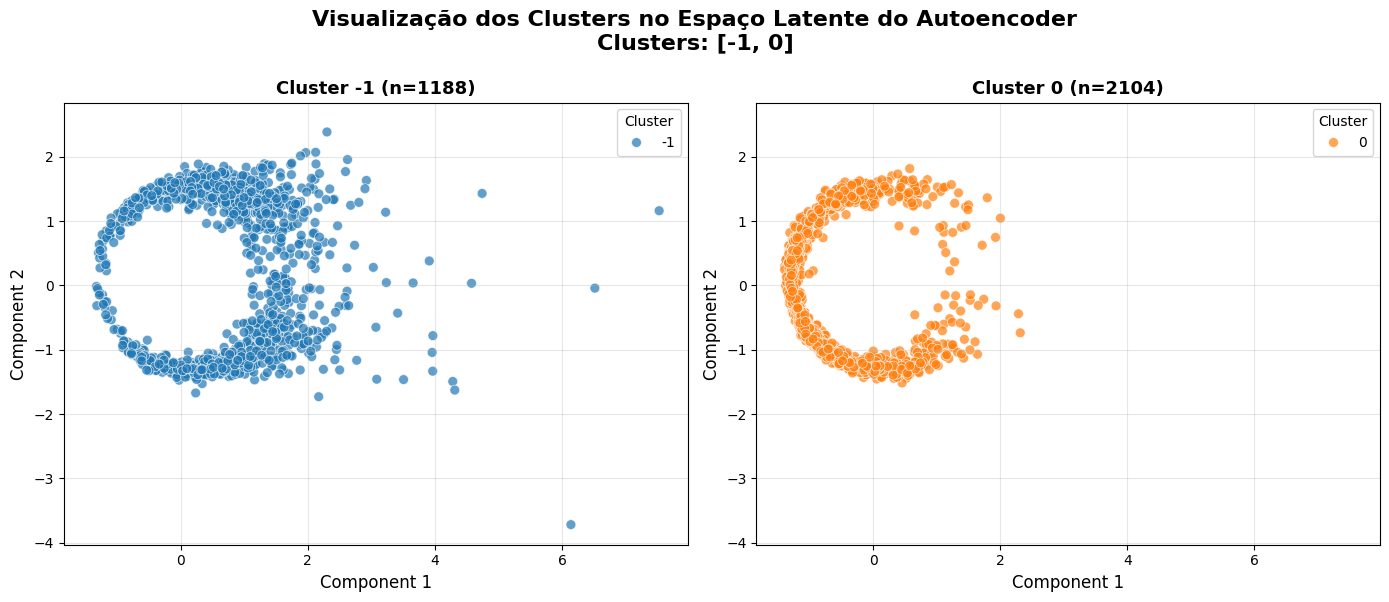

In [ ]:
helper.show_clustered_autoencoder(
    selected_clusters=selected_clusters,
    # savepath=IMAGES_SAVE_PATH + "shade-autoencoder-all",
)

##### Future data


2026-02-05 16:32:42,333 - Modules.FutureAnalysisModule - WARNING - 84 subject_ids in target data are missing from reference data. These will be filtered out.
2026-02-05 16:32:42,337 - Modules.FutureAnalysisModule - WARNING - 551 subject_ids in target data are missing from reference data. These will be filtered out.
2026-02-05 16:32:42,351 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 3649 records
2026-02-05 16:32:42,360 - Modules.FutureAnalysisModule - INFO - Auto-detected 19 binary features for analysis
2026-02-05 16:32:42,381 - Modules.FutureAnalysisModule - INFO - Delta clusters calculated for 1 clusters
2026-02-05 16:32:42,383 - Modules.FutureAnalysisModule - INFO - FutureAnalysisHelper initialized with 3355 past records and 2257 future records
2026-02-05 16:32:42,388 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 976 records
2026-02-05 16:32:42,391 - Modules.FutureAnalysisModule - INFO - Auto-detected 20 binary features for analysis
2026-02-05 16:32:

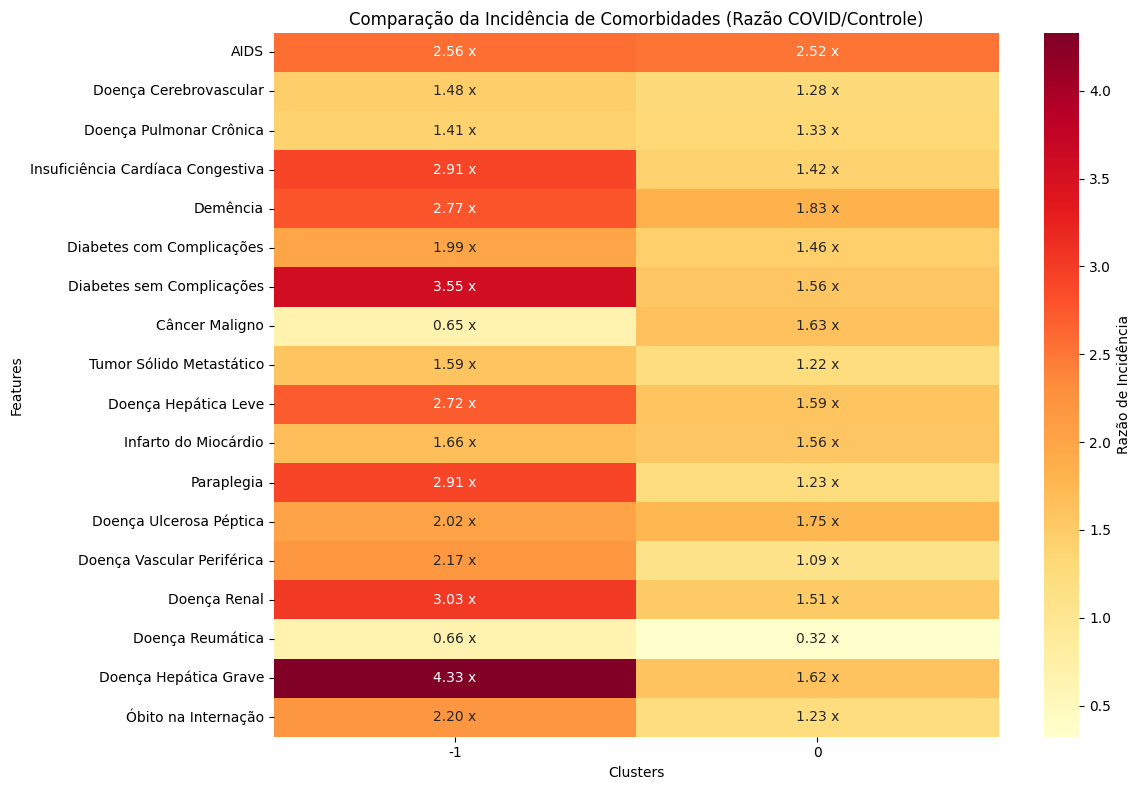

In [ ]:
future_helper = fa.FutureAnalysisHelper(
    helper.clustered_data, future_data, control, control_readmission
)
delta = future_helper.get_delta_clusters(percentage=True, relative_total=True)
future_helper.show_delta_heatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    relative_total=True,
    selected_clusters=selected_clusters,
    savepath=IMAGES_SAVE_PATH + "shade-all-future",
)

In [113]:
future_helper.get_mean_readmission()

2026-02-05 16:32:42,565 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 2257 records
2026-02-05 16:32:42,568 - Modules.FutureAnalysisModule - INFO - Calculated mean readmission for 5 clusters


{'Mean readmission Cluster -1': np.float64(2.55),
 'Mean readmission Cluster 0': np.float64(2.16),
 'Mean readmission Cluster 1': np.float64(1.9),
 'Mean readmission Cluster 2': np.float64(4.4),
 'Mean readmission Cluster 3': np.float64(1.67),
 'Overall Mean readmission': 2.31}

In [114]:
future_helper.get_mean_days_gap()

2026-02-05 16:32:42,577 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 976 records
2026-02-05 16:32:42,578 - Modules.FutureAnalysisModule - INFO - Calculated mean days gap for 5 clusters


{'Mean days gap Cluster -1': np.float64(123.85),
 'Mean days gap Cluster 0': np.float64(129.64),
 'Mean days gap Cluster 1': np.float64(211.33),
 'Mean days gap Cluster 2': np.float64(65.92),
 'Mean days gap Cluster 3': np.float64(50.07),
 'Overall Mean days gap': 127.49}

In [115]:
future_helper.get_mortality_rates(only_first_admission=True)

2026-02-05 16:32:42,617 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 976 records
2026-02-05 16:32:42,624 - Modules.FutureAnalysisModule - INFO - Calculated mortality rates for 5 clusters


{'Mortality rate Cluster -1': 0.07,
 'Mortality rate Cluster 0': 0.15,
 'Mortality rate Cluster 1': 0.0,
 'Mortality rate Cluster 2': 0.0,
 'Mortality rate Cluster 3': 0.0,
 'Overall Mortality rate': 0.09}

### Add Logs

In [116]:
# log_file = "../log.csv"
# current_dir = os.getcwd()
# log_file_path = os.path.join(current_dir, log_file)

# metrics = helper.getMetrics()

# # Add line to save log
# if os.path.exists(log_file_path):
#     with open(log_file_path, 'a') as f:
#         f.write(f"Shade, None, Comprehensive, {metrics['disco']}, {metrics['dbcv']}, {metrics['dsi']}, {metrics['silhouette']}\n")